# Mistral OCR-4 — LLM-as-Judge Evaluation

This notebook measures OCR-4 performance across four tricky scenarios using **GPT-4.1 as an independent judge**.

| Scenario | Documents | What makes it hard |
|----------|-----------|-------------------|
| 1. Business table extraction | 5 invoices | Field alignment, mixed text/numbers, totals |
| 2. Sparse financial tables | P&L statements | Intentionally empty cells, multi-section layout |
| 3. Complex form parsing | DGD declarations | Multi-table, regulatory structure, dense fields |
| 4. Signature & special elements | DGD with signature block | Non-text element, block classification |

**Judge dimensions (1–10 each):**
- **Completeness** — were all fields/cells captured?
- **Accuracy** — are extracted values correct?
- **Structure** — is the table/form layout preserved?
- **Edge Case Handling** — blanks, signatures, ambiguous fields

> **Honest caveat:** All samples in this repo are high-quality digital PDFs (97–99% OCR confidence).
> True stress-tests (scanned handwriting, degraded images) would show a very different confidence distribution.
> The LLM judge is designed to surface semantic errors that confidence scores miss entirely.

## 0. Setup

In [1]:
import base64
import json
import os
import re
from pathlib import Path
from typing import Any, Dict, List
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import requests
from IPython.display import Markdown, display
from dotenv import load_dotenv

load_dotenv(dotenv_path='.env', override=False)

OCR_ENDPOINT   = os.getenv('AZURE_MISTRAL_DOCUMENT_AI_ENDPOINT')
OCR_MODEL      = os.getenv('AZURE_AI_DEPLOYMENT_NAME')
API_KEY        = os.getenv('AZURE_MISTRAL_DOCUMENT_AI_KEY')
JUDGE_ENDPOINT = (
    'https://<YOUR_FOUNDRY_RESOURCE>.services.ai.azure.com'
    '/openai/deployments/gpt-4.1/chat/completions'
    '?api-version=2024-10-21'
)

OCR_HEADERS   = {'Content-Type': 'application/json', 'Authorization': f'Bearer {API_KEY}'}
JUDGE_HEADERS = {'Content-Type': 'application/json', 'api-key': API_KEY}

SAMPLES = Path('samples')

print(f'OCR   : {OCR_ENDPOINT}')
print(f'Judge : GPT-4.1 via Azure AI Foundry')
print(f'Model : {OCR_MODEL}')


OCR   : https://<YOUR_FOUNDRY_RESOURCE>.services.ai.azure.com/providers/mistral/azure/ocr
Judge : GPT-4.1 via Azure AI Foundry
Model : mistral-ocr-4-0


In [2]:
def encode_file(path: str) -> str:
    with open(path, 'rb') as f:
        return base64.b64encode(f.read()).decode()

def run_ocr(file_path: str, mime: str = 'application/pdf') -> dict:
    payload = {
        'model': OCR_MODEL,
        'document': {
            'type': 'document_url',
            'document_url': f'data:{mime};base64,{encode_file(file_path)}',
        },
        'include_blocks': True,
        'table_format': 'markdown',
        'confidence_scores_granularity': 'page',
        'extract_header': True,
        'extract_footer': True,
    }
    resp = requests.post(OCR_ENDPOINT, json=payload, headers=OCR_HEADERS)
    resp.raise_for_status()
    return resp.json()

def full_markdown(ocr_response: dict) -> str:
    """Concatenate page markdown, inlining table content in place of [tbl-N.md] refs."""
    parts = []
    for p in ocr_response.get('pages', []):
        text = p.get('markdown', '')
        for tbl in (p.get('tables') or []):
            tbl_id      = tbl.get('id', '')
            tbl_content = (tbl.get('content') or '').strip()
            if tbl_id and tbl_content:
                text = text.replace(f'[{tbl_id}]({tbl_id})', tbl_content)
        parts.append(text)
    return '\n\n---\n\n'.join(parts)

def page_confidence(ocr_response: dict) -> List[float]:
    return [
        p['confidence_scores']['average_page_confidence_score']
        for p in ocr_response.get('pages', [])
        if p.get('confidence_scores', {}).get('average_page_confidence_score') is not None
    ]

def block_types(ocr_response: dict, page: int = 0) -> List[str]:
    pages = ocr_response.get('pages', [])
    if page < len(pages):
        return [b['type'] for b in (pages[page].get('blocks') or [])]
    return []

print('Helpers ready.')


Helpers ready.


## 1. LLM Judge Framework

The judge receives:
1. A **scenario description** (what the document is, what to evaluate)
2. The **OCR-extracted markdown**
3. A **rubric** with four dimensions

It returns a JSON object with scores and reasoning.

> **Why a judge over rule-based metrics?**  
> Rule-based evaluation requires ground truth. For real documents, you rarely have it.  
> A judge assesses *plausibility*, *semantic correctness*, and *structural coherence* without pre-labeled data.  
> It also catches subtle errors: a number extracted as `1.234` vs `1,234` is wrong but passes a regex match.

In [3]:
JUDGE_SYSTEM_PROMPT = (
    'You are an OCR quality evaluation expert. You assess the output of an OCR system '
    'applied to business documents.\n\n'
    'You will be given:\n'
    '- A scenario description (document type, what to look for)\n'
    '- The OCR-extracted markdown text\n\n'
    'Score the OCR output on four dimensions (1-10 each):\n'
    '1. Completeness: Were all fields, rows, and cells captured?\n'
    '2. Accuracy: Are extracted values semantically correct?\n'
    '3. Structure: Is the table/form layout preserved?\n'
    '4. Edge_Case_Handling: How well are blanks, ambiguous fields, '
    'signatures, and special characters handled?\n\n'
    'Return ONLY valid JSON:\n'
    '{\n'
    '  "completeness": <int 1-10>,\n'
    '  "accuracy": <int 1-10>,\n'
    '  "structure": <int 1-10>,\n'
    '  "edge_case_handling": <int 1-10>,\n'
    '  "overall": <float, average of the four>,\n'
    '  "strengths": ["<str>", "<str>"],\n'
    '  "weaknesses": ["<str>", "<str>"],\n'
    '  "critical_insight": "<one sentence: what confidence score does NOT tell you>"\n'
    '}'
)

def judge_ocr(scenario: str, ocr_markdown: str) -> Dict[str, Any]:
    user_msg = f'**Scenario:** {scenario}\n\n**OCR Output (markdown):**\n```\n{ocr_markdown[:6000]}\n```'
    payload = {
        'messages': [
            {'role': 'system', 'content': JUDGE_SYSTEM_PROMPT},
            {'role': 'user',   'content': user_msg},
        ],
        'max_tokens': 600,
        'temperature': 0.0,
    }
    resp = requests.post(JUDGE_ENDPOINT, json=payload, headers=JUDGE_HEADERS)
    resp.raise_for_status()
    raw = resp.json()['choices'][0]['message']['content'].strip()
    raw = re.sub(r'^```json\s*|```$', '', raw, flags=re.MULTILINE).strip()
    return json.loads(raw)

def display_verdict(label: str, verdict: Dict[str, Any], conf_scores: List[float]) -> None:
    dims   = ['completeness', 'accuracy', 'structure', 'edge_case_handling']
    scores = [verdict[d] for d in dims]
    avg_conf = round(float(np.mean(conf_scores)), 3) if conf_scores else None
    print(f'\n{"─"*60}')
    print(f'  {label}')
    print(f'{"─"*60}')
    print(f'  OCR avg confidence : {avg_conf}')
    print(f'  Judge overall      : {verdict["overall"]:.1f} / 10')
    print()
    labels = ['Completeness', 'Accuracy', 'Structure', 'Edge Cases']
    for lbl, score in zip(labels, scores):
        bar = '█' * score + '░' * (10 - score)
        print(f'  {lbl:<18} {bar}  {score}/10')
    print()
    for s in verdict.get('strengths', []):
        print(f'  + {s}')
    for w in verdict.get('weaknesses', []):
        print(f'  - {w}')
    print(f'  → {verdict.get("critical_insight", "")}')

print('Judge framework ready.')


Judge framework ready.


---
## Scenario 1 — Business Invoice Extraction

Five invoices of increasing complexity. Tests field alignment, line-item tables, totals, and address fields.

Invoices are a *baseline*: the model should score very high here. Any drop-off reveals structural or accuracy weaknesses.

In [4]:
INVOICE_DIR = SAMPLES / 'test_docs' / 'Invoice'
invoice_files = sorted(INVOICE_DIR.glob('*.pdf'))

print(f'Running OCR on {len(invoice_files)} invoices...')
invoice_results = []
for f in invoice_files:
    ocr     = run_ocr(str(f))
    md_text = full_markdown(ocr)
    confs   = page_confidence(ocr)
    verdict = judge_ocr(
        scenario=(
            'Business invoice PDF. Evaluate whether all line items, quantities, unit prices, '
            'subtotals, taxes, shipping costs, and totals were extracted. '
            'Check for missing rows, garbled numbers, and misaligned table columns. '
            'Note any empty or ambiguous fields.'
        ),
        ocr_markdown=md_text,
    )
    invoice_results.append({'file': f.name, 'ocr_confidence': round(float(np.mean(confs)), 3), 'verdict': verdict})
    display_verdict(f.name, verdict, confs)


Running OCR on 5 invoices...



────────────────────────────────────────────────────────────
  invoice_1.pdf
────────────────────────────────────────────────────────────
  OCR avg confidence : 0.976
  Judge overall      : 8.0 / 10

  Completeness       ████████░░  8/10
  Accuracy           █████████░  9/10
  Structure          ████████░░  8/10
  Edge Cases         ███████░░░  7/10

  + All key invoice fields (line item, quantities, rates, subtotals, totals) are present and values are legible.
  + Table structure is mostly preserved, with clear separation of summary rows.
  - Only one line item is present; it's unclear if more were on the original document.
  - Summary rows (Subtotal, Discount, Shipping, Total) are not clearly separated from line items and use empty cells for labels, which may cause confusion.
  → A high confidence score does not reveal if some line items or fields were entirely missed or omitted by the OCR.



────────────────────────────────────────────────────────────
  invoice_2.pdf
────────────────────────────────────────────────────────────
  OCR avg confidence : 0.978
  Judge overall      : 8.2 / 10

  Completeness       ████████░░  8/10
  Accuracy           ██████████  10/10
  Structure          ████████░░  8/10
  Edge Cases         ███████░░░  7/10

  + All key invoice fields (line item, quantities, prices, subtotals, tax, total) are present and values are correct.
  + Contact and payment details are accurately captured.
  - Table structure is somewhat fragmented, with summary fields outside the main line item table.
  - No explicit handling of empty or ambiguous fields (e.g., shipping cost is missing or not marked as blank).
  → A high confidence score does not guarantee that all expected fields (like shipping cost) are present or that the table structure matches the original document.



────────────────────────────────────────────────────────────
  invoice_3.pdf
────────────────────────────────────────────────────────────
  OCR avg confidence : 0.972
  Judge overall      : 6.8 / 10

  Completeness       ██████░░░░  6/10
  Accuracy           █████████░  9/10
  Structure          ███████░░░  7/10
  Edge Cases         █████░░░░░  5/10

  + Extracted values for line items, subtotals, credits, and totals are accurate and consistent across pages.
  + Table formatting is mostly preserved, making the data readable and structured.
  - Key invoice fields such as quantity, unit price, taxes, and shipping costs are missing or not extracted.
  - No handling or explicit marking of empty/ambiguous fields (e.g., blank cells, missing columns), and repeated identical tables suggest possible page duplication without differentiation.
  → A high confidence score does not reveal missing fields or columns that were never extracted, such as quantities or taxes.



────────────────────────────────────────────────────────────
  invoice_4.pdf
────────────────────────────────────────────────────────────
  OCR avg confidence : 0.97
  Judge overall      : 7.5 / 10

  Completeness       ███████░░░  7/10
  Accuracy           █████████░  9/10
  Structure          ████████░░  8/10
  Edge Cases         ██████░░░░  6/10

  + All major invoice fields (date, customer number, invoice number, total, due date) are present and correct.
  + Table structure for summary of charges is preserved with correct line items and amounts.
  - Tax fields (GST, HST, PST/QST) are present in the table header but have no values, and HST details are referenced but not extracted.
  - Some fields (e.g., Amount paid, Signature) are blank or ambiguous, and shipping costs are not explicitly listed.
  → A high confidence score does not guarantee that all required financial details (like taxes or shipping) are actually present or correctly extracted.



────────────────────────────────────────────────────────────
  invoice_5.pdf
────────────────────────────────────────────────────────────
  OCR avg confidence : 0.967
  Judge overall      : 7.0 / 10

  Completeness       ███████░░░  7/10
  Accuracy           ████████░░  8/10
  Structure          ███████░░░  7/10
  Edge Cases         ██████░░░░  6/10

  + All major line items and their amounts are present
  + Key invoice fields (date, invoice number, bill to) are captured
  - Table contains several empty rows, possibly indicating missing data or poor structure preservation
  - No explicit extraction of subtotals, taxes, or shipping costs—these fields may be missing or not present in the source
  → A high confidence score does not guarantee that all required financial fields (like taxes or shipping) are present or that the table structure matches the original document.


In [5]:
rows = []
for r in invoice_results:
    v = r['verdict']
    rows.append({'File': r['file'], 'OCR Conf': r['ocr_confidence'],
                 'Completeness': v['completeness'], 'Accuracy': v['accuracy'],
                 'Structure': v['structure'], 'Edge Cases': v['edge_case_handling'],
                 'Overall': round(v['overall'], 1)})
df_inv = pd.DataFrame(rows)
display(df_inv.set_index('File').style.background_gradient(
    subset=['Completeness','Accuracy','Structure','Edge Cases','Overall'],
    cmap='RdYlGn', vmin=1, vmax=10
))


,OCR Conf,Completeness,Accuracy,Structure,Edge Cases,Overall
File,,,,,,
invoice_1.pdf,0.976000,8,9,8,7,8.000000
invoice_2.pdf,0.978000,8,10,8,7,8.200000
invoice_3.pdf,0.972000,6,9,7,5,6.800000
invoice_4.pdf,0.970000,7,9,8,6,7.500000
invoice_5.pdf,0.967000,7,8,7,6,7.000000


---
## Scenario 2 — Sparse Financial Tables (P&L Statements)

P&L statements have intentionally empty cells — no value for a period means *genuinely blank*, not zero.

This tests whether the OCR system distinguishes *missing data* from *absent rows*, and whether multi-section tables (Income, Expenses, Net) stay structurally separate.

In [6]:
PL_DIR = SAMPLES / 'test_docs' / 'P&L'
pl_files = sorted(PL_DIR.iterdir())

print(f'Running OCR on {len(pl_files)} P&L documents...')
pl_results = []
for f in pl_files:
    mime    = 'image/png' if f.suffix.lower() == '.png' else 'application/pdf'
    ocr     = run_ocr(str(f), mime=mime)
    md_text = full_markdown(ocr)
    confs   = page_confidence(ocr)
    verdict = judge_ocr(
        scenario=(
            'Profit and Loss statement. Pay special attention to: '
            '(1) Are blank/empty cells preserved as empty rather than filled with zero or omitted? '
            '(2) Are multi-section tables (Income, Expenses, Net Income) kept structurally separate? '
            '(3) Are subtotals and totals correctly captured without row-shifting?'
        ),
        ocr_markdown=md_text,
    )
    pl_results.append({'file': f.name, 'ocr_confidence': round(float(np.mean(confs)), 3), 'verdict': verdict})
    display_verdict(f.name, verdict, confs)


Running OCR on 5 P&L documents...



────────────────────────────────────────────────────────────
  P&L_1.png
────────────────────────────────────────────────────────────
  OCR avg confidence : 0.985
  Judge overall      : 9.5 / 10

  Completeness       ██████████  10/10
  Accuracy           █████████░  9/10
  Structure          ██████████  10/10
  Edge Cases         █████████░  9/10

  + All fields, rows, and sections (Income, Expenses, Net Income) are present and clearly separated.
  + Subtotals and totals are correctly labeled and positioned, preserving the logical flow of the statement.
  - Use of '-' for Interest Revenue may not distinguish between true zero and missing/blank values.
  - Bold formatting for totals is preserved in markdown but may not be semantically tagged for downstream processing.
  → A high confidence score does not guarantee that the OCR system correctly distinguishes between blank, zero, and missing values, which can impact financial interpretation.



────────────────────────────────────────────────────────────
  P&L_2.pdf
────────────────────────────────────────────────────────────
  OCR avg confidence : 0.98
  Judge overall      : 9.0 / 10

  Completeness       █████████░  9/10
  Accuracy           ██████████  10/10
  Structure          █████████░  9/10
  Edge Cases         ████████░░  8/10

  + All major sections (Income, Expenses, Profit/Loss) are present and clearly separated.
  + All values, subtotals, and totals are accurately captured with correct formatting.
  - No explicit handling of blank/empty cells is demonstrated, as all fields are filled.
  - Table headers are repeated for each section, which may not reflect the original document's structure perfectly.
  → A high confidence score does not guarantee that blank or ambiguous fields are handled correctly, especially if the sample lacks such cases.



────────────────────────────────────────────────────────────
  P&L_3.pdf
────────────────────────────────────────────────────────────
  OCR avg confidence : 0.983
  Judge overall      : 8.0 / 10

  Completeness       █████████░  9/10
  Accuracy           ████████░░  8/10
  Structure          ████████░░  8/10
  Edge Cases         ███████░░░  7/10

  + Multi-section structure (Revenue, Cost of Sales, Other Income, Expenses) is mostly preserved.
  + Subtotals and totals are clearly labeled and generally in the correct rows.
  - Some blank cells are filled with zeros (e.g., Freight & Courier, Travel, General Expenses), which may not reflect the original intent.
  - There is a repeated label ('Total Revenue') under Cost of Sales, which is likely an OCR mislabeling.
  → A high confidence score does not guarantee that semantic errors (like mislabeling totals or misrepresenting blanks as zeros) are absent.



────────────────────────────────────────────────────────────
  P&L_4.pdf
────────────────────────────────────────────────────────────
  OCR avg confidence : 0.992
  Judge overall      : 9.5 / 10

  Completeness       ██████████  10/10
  Accuracy           ██████████  10/10
  Structure          █████████░  9/10
  Edge Cases         █████████░  9/10

  + All fields, rows, and cells are captured, including subtotals and totals.
  + Blank/empty cells are preserved as empty, not filled with zeros or omitted.
  - Some minor inconsistencies in table formatting (e.g., column alignment in multi-column tables).
  - Section separation could be clearer; the use of markdown headers and horizontal rules is good but not perfect for automated parsing.
  → A high confidence score does not guarantee that the logical separation of multi-section tables or the preservation of complex table structures is perfect.



────────────────────────────────────────────────────────────
  P&L_5.pdf
────────────────────────────────────────────────────────────
  OCR avg confidence : 0.996
  Judge overall      : 8.0 / 10

  Completeness       ████████░░  8/10
  Accuracy           █████████░  9/10
  Structure          ████████░░  8/10
  Edge Cases         ███████░░░  7/10

  + Multi-section tables (Income, Expenses, etc.) are clearly separated with headings and markdown tables.
  + Subtotals and totals are generally captured and labeled correctly, with bold formatting preserved.
  - Some sections are truncated (e.g., 'Insur' at the end), indicating incomplete extraction.
  - Blank cells are inconsistently handled: some are left empty, but many are filled with '0.00', which may not reflect the original intent.
  → A high confidence score does not guarantee that all blank or ambiguous fields are faithfully represented as in the source document.


In [7]:
rows = []
for r in pl_results:
    v = r['verdict']
    rows.append({'File': r['file'], 'OCR Conf': r['ocr_confidence'],
                 'Completeness': v['completeness'], 'Accuracy': v['accuracy'],
                 'Structure': v['structure'], 'Edge Cases': v['edge_case_handling'],
                 'Overall': round(v['overall'], 1)})
df_pl = pd.DataFrame(rows)
display(df_pl.set_index('File').style.background_gradient(
    subset=['Completeness','Accuracy','Structure','Edge Cases','Overall'],
    cmap='RdYlGn', vmin=1, vmax=10
))


,OCR Conf,Completeness,Accuracy,Structure,Edge Cases,Overall
File,,,,,,
P&L_1.png,0.985000,10,9,10,9,9.500000
P&L_2.pdf,0.980000,9,10,9,8,9.000000
P&L_3.pdf,0.983000,9,8,8,7,8.000000
P&L_4.pdf,0.992000,10,10,9,9,9.500000
P&L_5.pdf,0.996000,8,9,8,7,8.000000


---
## Scenario 3 — Complex Regulatory Forms (DGD Declarations)

Dangerous Goods Declaration forms are dense, multi-table regulatory documents with strict field ordering and legal significance.

This stress-tests block classification: does the model correctly separate distinct tables and identify all required regulatory fields?

In [8]:
DGD_DIR = SAMPLES / 'test_docs' / 'DGD'
dgd_files = sorted(DGD_DIR.glob('*.pdf'))

print(f'Running OCR on {len(dgd_files)} DGD forms...')
dgd_results = []
for f in dgd_files:
    ocr     = run_ocr(str(f))
    md_text = full_markdown(ocr)
    confs   = page_confidence(ocr)
    btypes  = block_types(ocr, page=0)
    has_sig = 'signature' in btypes
    verdict = judge_ocr(
        scenario=(
            'Dangerous Goods Declaration (DGD) — dense regulatory shipping form. '
            'Contains multiple tables: shipper/consignee, commodity details (UN number, '
            'proper shipping name, quantity, packing group), and transport certifications. '
            'Evaluate: (1) Are all tables captured as separate structures? '
            '(2) Are UN numbers, hazard class, and quantity fields extracted? '
            '(3) Are certification/signature sections preserved?'
        ),
        ocr_markdown=md_text,
    )
    dgd_results.append({
        'file': f.name, 'ocr_confidence': round(float(np.mean(confs)), 3),
        'has_signature_block': has_sig, 'block_types': btypes, 'verdict': verdict,
    })
    sig_note = '  *** Signature block detected ***' if has_sig else ''
    print(f'Blocks: {btypes}{sig_note}')
    display_verdict(f.name, verdict, confs)


Running OCR on 6 DGD forms...


Blocks: ['title', 'text', 'table']

────────────────────────────────────────────────────────────
  2025_10_17DG DECLARATION FORM_Paint.pdf
────────────────────────────────────────────────────────────
  OCR avg confidence : 0.978
  Judge overall      : 7.5 / 10

  Completeness       ████████░░  8/10
  Accuracy           █████████░  9/10
  Structure          ██████░░░░  6/10
  Edge Cases         ███████░░░  7/10

  + Key regulatory fields such as UN number, hazard class, and quantity are present and accurately extracted.
  + Certification and signature sections are captured with signatory names, roles, and dates.
  - Multiple tables are merged into a single large table, losing clear separation between shipper/consignee, commodity details, and certifications.
  - Some fields (e.g., chemical name, inner packing) are blank or ambiguously represented, and checkboxes are not clearly marked.
  → A high confidence score does not guarantee that the document's logical structure or regulatory comp

Blocks: ['title', 'text', 'table']

────────────────────────────────────────────────────────────
  a_chlorine.pdf
────────────────────────────────────────────────────────────
  OCR avg confidence : 0.987
  Judge overall      : 7.5 / 10

  Completeness       ████████░░  8/10
  Accuracy           █████████░  9/10
  Structure          ██████░░░░  6/10
  Edge Cases         ███████░░░  7/10

  + All major fields and required data (UN number, hazard class, quantity, signatures) are present and readable.
  + Certification and signature sections are included with declarant names and dates.
  - Table structure is flattened into a single large table, losing separation between logical sections (e.g., shipper/consignee vs. commodity details).
  - Some fields (e.g., blank cells, ambiguous multi-line fields) are not clearly delineated or are merged, making parsing difficult.
  → A high confidence score does not guarantee that the document's logical structure or regulatory compliance requirements are

Blocks: ['title', 'text', 'table']

────────────────────────────────────────────────────────────
  a_corrosive2.pdf
────────────────────────────────────────────────────────────
  OCR avg confidence : 0.985
  Judge overall      : 8.2 / 10

  Completeness       █████████░  9/10
  Accuracy           █████████░  9/10
  Structure          ████████░░  8/10
  Edge Cases         ███████░░░  7/10

  + All major tables and sections (shipper/consignee, commodity details, certifications) are present and mostly complete.
  + Key regulatory fields such as UN number, hazard class, quantity, and signatures are captured with high fidelity.
  - Some table rows are merged or have multi-field cells, making it harder to parse as distinct tables.
  - Edge cases like blank fields, ambiguous signature placements, and special formatting (e.g., bold, footnotes) are not always clearly distinguished.
  → A high confidence score does not guarantee that the logical separation of tables or the nuanced handling of si

Blocks: ['title', 'table', 'text', 'text', 'signature', 'text', 'text', 'text', 'text', 'text', 'text', 'table', 'table']  *** Signature block detected ***

────────────────────────────────────────────────────────────
  a_cynadine_truck (2).pdf
────────────────────────────────────────────────────────────
  OCR avg confidence : 0.98
  Judge overall      : 7.8 / 10

  Completeness       ████████░░  8/10
  Accuracy           █████████░  9/10
  Structure          ███████░░░  7/10
  Edge Cases         ███████░░░  7/10

  + Key fields such as UN number, hazard class (implied by commodity), and quantity are present and accurate.
  + Certification and signature sections are captured, including declarant names and dates.
  - Table separation is unclear; multiple logical tables are merged or not distinctly separated.
  - Some fields (e.g., hazard class, packing group) are not explicitly labeled or are embedded in text, reducing clarity.
  → A high confidence score does not guarantee that the doc

Blocks: ['title', 'table']

────────────────────────────────────────────────────────────
  a_fertilisers.pdf
────────────────────────────────────────────────────────────
  OCR avg confidence : 0.989
  Judge overall      : 7.5 / 10

  Completeness       ████████░░  8/10
  Accuracy           ████████░░  8/10
  Structure          ███████░░░  7/10
  Edge Cases         ███████░░░  7/10

  + Key fields such as shipper, consignee, UN number, and signatures are present and readable.
  + Most tables and sections are captured, with clear demarcation of major form areas.
  - Commodity details (e.g., hazard class, packing group) are not explicitly separated or labeled as in the original form.
  - Some fields (e.g., blank cells, ambiguous multi-line fields) are merged or not clearly structured, and table separation is weak.
  → A high confidence score does not guarantee that all regulatory-required fields are distinctly extracted or that table boundaries are faithfully preserved.


Blocks: ['title', 'text', 'table']

────────────────────────────────────────────────────────────
  a_gasoline2 (1).pdf
────────────────────────────────────────────────────────────
  OCR avg confidence : 0.985
  Judge overall      : 8.2 / 10

  Completeness       █████████░  9/10
  Accuracy           █████████░  9/10
  Structure          ███████░░░  7/10
  Edge Cases         ████████░░  8/10

  + All major tables and fields, including shipper/consignee, commodity details, and certification sections, are present.
  + Key regulatory fields such as UN number, hazard class, quantity, and signatures are captured with high fidelity.
  - Table structure is somewhat flattened; multiple logical tables are merged into a single large table, reducing clarity.
  - Some edge cases like blank cells and signature fields are present but not always clearly demarcated or separated from adjacent content.
  → A high confidence score does not guarantee that the logical separation of tables or the contextual 

In [9]:
rows = []
for r in dgd_results:
    v = r['verdict']
    rows.append({'File': r['file'][:38], 'OCR Conf': r['ocr_confidence'],
                 'Sig Block': 'Yes' if r['has_signature_block'] else 'No',
                 'Completeness': v['completeness'], 'Accuracy': v['accuracy'],
                 'Structure': v['structure'], 'Edge Cases': v['edge_case_handling'],
                 'Overall': round(v['overall'], 1)})
df_dgd = pd.DataFrame(rows)
display(df_dgd.set_index('File').style.background_gradient(
    subset=['Completeness','Accuracy','Structure','Edge Cases','Overall'],
    cmap='RdYlGn', vmin=1, vmax=10
))


,OCR Conf,Sig Block,Completeness,Accuracy,Structure,Edge Cases,Overall
File,,,,,,,
2025_10_17DG DECLARATION FORM_Paint.pd,0.978000,No,8,9,6,7,7.500000
a_chlorine.pdf,0.987000,No,8,9,6,7,7.500000
a_corrosive2.pdf,0.985000,No,9,9,8,7,8.200000
a_cynadine_truck (2).pdf,0.980000,Yes,8,9,7,7,7.800000
a_fertilisers.pdf,0.989000,No,8,8,7,7,7.500000
a_gasoline2 (1).pdf,0.985000,No,9,9,7,8,8.200000


---
## Scenario 4 — Signature Detection & Special Elements

`a_cynadine_truck` is the one sample where OCR-4 detects a **`signature` block type**.

Three questions:
1. Is the block correctly classified?
2. What content does OCR extract from the signature region?
3. Does the page minimum confidence correlate with the ambiguous region?

> **Critical insight:** OCR models are not handwriting recognisers.
> A signature block with minimal text extraction is *expected and correct* — the value is knowing the signature *exists* and *where*, not reading it.

In [10]:
SIG_DOC = SAMPLES / 'test_docs' / 'DGD' / 'a_cynadine_truck (2).pdf'

ocr_sig = run_ocr(str(SIG_DOC))
p0      = ocr_sig['pages'][0]
confs   = page_confidence(ocr_sig)
min_conf = p0.get('confidence_scores', {}).get('minimum_page_confidence_score')

print('Block sequence on page 0:')
for i, b in enumerate(p0.get('blocks') or []):
    preview = b['content'][:70].replace('\n', ' ')
    marker  = ' <<< SIGNATURE' if b['type'] == 'signature' else ''
    print(f'  [{i:02d}] {b["type"]:12s}  {preview}{marker}')

print(f'\nPage avg confidence : {confs[0]:.4f}')
print(f'Page min confidence : {min_conf:.4f}' if min_conf else 'Page min: n/a')


Block sequence on page 0:
  [00] title         # IMO DANGEROUS GOODS DECLARATION
  [01] table         |  1 Shipper Cyanco (Cyanco International, LLC) 1 Monsanto Road, FM 29
  [02] text          **SHIPPER'S DECLARATION**
  [03] text          I hereby declare that the contents of this consignment are fully and a
  [04] signature      <<< SIGNATURE
  [05] text          10 Vessel/Flight and Date
  [06] text          MV Maersk Atlanta - 12 October 2025
  [07] text          9 Additional Handling Information
  [08] text          Kepp dry. Toxic. Handle with care.
  [09] text          11 Port/Place Handling
  [10] text          124 Monsanto, Texas, United States.
  [11] table         |  14 Shipping Marks | Number and Kind of Packages, Description of Goo
  [12] table         |  15 CTU ID No. RRR2233445 | 16 Seal No. CY001234 | 17 CTU Size and T

Page avg confidence : 0.9808
Page min confidence : 0.2167


In [11]:
sig_blocks = [b for b in (p0.get('blocks') or []) if b['type'] == 'signature']
print(f'Signature blocks: {len(sig_blocks)}')
for i, sb in enumerate(sig_blocks):
    w = sb['bottom_right_x'] - sb['top_left_x']
    h = sb['bottom_right_y'] - sb['top_left_y']
    print(f'  Block {i}: bbox ({sb["top_left_x"]},{sb["top_left_y"]}) '
          f'-> ({sb["bottom_right_x"]},{sb["bottom_right_y"]})  [{w}x{h}px]')
    print(f'  Content: "{sb["content"][:200]}"')

verdict_sig = judge_ocr(
    scenario=(
        'Dangerous Goods Declaration containing a handwritten signature region. '
        'Focus on: (1) Is the signature region correctly identified and not confused with text? '
        '(2) Is surrounding context (certifier name, date, declaration fields) captured? '
        '(3) Does the OCR handle the non-text element without hallucinating content?'
    ),
    ocr_markdown=full_markdown(ocr_sig),
)
display_verdict('a_cynadine_truck — Signature Focus', verdict_sig, confs)


Signature blocks: 1
  Block 0: bbox (44,284) -> (234,315)  [190x31px]
  Content: ""



────────────────────────────────────────────────────────────
  a_cynadine_truck — Signature Focus
────────────────────────────────────────────────────────────
  OCR avg confidence : 0.981
  Judge overall      : 8.8 / 10

  Completeness       █████████░  9/10
  Accuracy           █████████░  9/10
  Structure          ████████░░  8/10
  Edge Cases         █████████░  9/10

  + Signature region is clearly labeled and not confused with text.
  + All key fields (certifier name, date, declaration fields) are present and context is preserved.
  - Table structure is somewhat flattened and multi-row fields are not perfectly aligned.
  - Some minor layout artifacts (e.g., empty cells, merged fields) reduce clarity.
  → A high confidence score does not guarantee that non-text elements like signatures are correctly identified or that table structure is faithfully preserved.


---
## Scenario 5 — Multilingual: Honest Assessment

The comprehensive showcase tested 8 European languages on a **PIL-rendered synthetic image** — pixel-perfect digital text, the *easiest* possible OCR input.

This section uses the same synthetic approach but runs it through the judge to illustrate the **confidence score trap**:

| Input type | Expected confidence | Real challenge? |
|------------|---------------------|----------------|
| Digital PDF / printed text | 97–99% | No |
| PIL-rendered synthetic image | 95–99% | No |
| Scanned printed document | 85–97% | Moderate |
| Scanned handwritten text | 40–80% | Yes |
| Degraded / low-res scan | 30–70% | Severe |

All samples in this repo sit in the top row.

In [12]:
from PIL import Image, ImageDraw
from io import BytesIO

def make_multilingual_image() -> bytes:
    rows = [
        ('English',    'Invoice #12345  Total: $1,234.56  Date: 15 Aug 2025'),
        ('Espanol',    'Factura #67890  Total: 2.345,67 EUR  Fecha: 15 ago 2025'),
        ('Francais',   'Facture #11111  Total: 1 234,56 EUR  Date: 15 aout 2025'),
        ('Deutsch',    'Rechnung #22222  Gesamt: 1.234,56 EUR  Datum: 15. Aug. 2025'),
        ('Italiano',   'Fattura #33333  Totale: 1.234,56 EUR  Data: 15 ago 2025'),
        ('Portugues',  'Fatura #44444   Total: R$ 1.234,56  Data: 15 ago 2025'),
        ('Polski',     'Faktura #55555  Razem: 1 234,56 PLN  Data: 15 sie 2025'),
        ('Nederlands', 'Factuur #66666  Totaal: 1.234,56 EUR  Datum: 15 aug 2025'),
    ]
    img  = Image.new('RGB', (860, len(rows)*44+50), color=(255,255,255))
    draw = ImageDraw.Draw(img)
    draw.rectangle([(0,0),(860,38)], fill=(44,62,80))
    draw.text((12,10), 'Mistral OCR-4 — Multilingual Invoice Fragments (8 languages)', fill=(255,255,255))
    for i, (lang, text) in enumerate(rows):
        y  = 44 + i*44
        bg = (248,248,248) if i%2==0 else (255,255,255)
        draw.rectangle([(0,y),(860,y+42)], fill=bg)
        draw.text((10,y+6),  f'[{lang}]', fill=(52,73,94))
        draw.text((120,y+6), text,         fill=(0,0,0))
    buf = BytesIO()
    img.save(buf, 'PNG')
    return buf.getvalue()

img_bytes = make_multilingual_image()
b64_ml    = base64.b64encode(img_bytes).decode()

ocr_ml_resp = requests.post(OCR_ENDPOINT, json={
    'model': OCR_MODEL,
    'document': {'type': 'document_url', 'document_url': 'data:image/png;base64,' + b64_ml},
    'confidence_scores_granularity': 'word',
    'include_blocks': True,
}, headers=OCR_HEADERS)
ocr_ml_resp.raise_for_status()
ocr_ml = ocr_ml_resp.json()

p_ml     = ocr_ml['pages'][0]
md_ml    = p_ml.get('markdown', '')
conf_ml  = p_ml.get('confidence_scores', {})
confs_ml = [conf_ml.get('average_page_confidence_score', 0)]

print('=== Extracted markdown ===')
print(md_ml)
print(f'\nPage avg confidence : {conf_ml.get("average_page_confidence_score", "n/a")}')
print(f'Page min confidence : {conf_ml.get("minimum_page_confidence_score", "n/a")}')


=== Extracted markdown ===
|  Mistral OCR-4 Multilingual Invoice Fragments (8 languages)  |   |
| --- | --- |
|  [English] | Invoice #12345 Total: $1,234.56 Date: 15 Aug 2025  |
|  [Espanol] | Factura #67890 Total: 2,345.67 EUR Fecha: 15 ago 2025  |
|  [Français] | Facture #11111 Total: 1 234,56 EUR Date: 15 aout 2025  |
|  [Deutsch] | Rechnung #22222 Gesamt: 1.234,56 EUR Datum: 15. Aug. 2025  |
|  [Italiano] | Fattura #33333 Total: 1.234,56 EUR Data: 15 ago 2025  |
|  [Portugues] | Fatura #44444 Total: R$ 1.234,56 Data: 15 ago 2025  |
|  [Polski] | Faktura #55555 Razem: 1 234,56 PLN Data: 15 sie 2025  |
|  [Nederlands] | Factuur #66666 Totaal: 1.234,56 EUR Datum: 15 aug 2025  |

Page avg confidence : 0.9853267227845247
Page min confidence : 0.5602780570832535


In [13]:
verdict_ml = judge_ocr(
    scenario=(
        'Synthetic image with 8 invoice fragments each in a different European language. '
        'Check: (1) Are accented/special characters correct (u-umlaut, n-tilde, c-cedilla, etc.)? '
        '(2) Are number formats preserved as written (e.g. 2.345,67 vs 1,234.56)? '
        '(3) Are language labels like [Espanol] captured verbatim?'
    ),
    ocr_markdown=md_ml,
)
display_verdict('Multilingual synthetic image (8 EU languages)', verdict_ml, confs_ml)

word_scores = conf_ml.get('word_confidence_scores', [])
if word_scores:
    low = sorted([w for w in word_scores if w['confidence'] < 0.85], key=lambda x: x['confidence'])
    if low:
        print('Low-confidence words (< 0.85):')
        for w in low[:8]:
            print(f'  {repr(w.get("word","?")):<20}  conf={w["confidence"]:.3f}')
    else:
        print('No words below 0.85 — synthetic rendered text is trivially easy for OCR.')
        print('This is the key limitation: high confidence on synthetic != robust on real scanned docs.')



────────────────────────────────────────────────────────────
  Multilingual synthetic image (8 EU languages)
────────────────────────────────────────────────────────────
  OCR avg confidence : 0.985
  Judge overall      : 8.5 / 10

  Completeness       ██████████  10/10
  Accuracy           ████████░░  8/10
  Structure          █████████░  9/10
  Edge Cases         ███████░░░  7/10

  + All invoice fragments and language labels are present and correctly segmented.
  + Number formats (decimal/thousand separators) are mostly preserved as written for each language.
  - Some accented/special characters are missing or incorrect (e.g., 'aout' instead of 'août', 'Portugues' instead of 'Português').
  - Edge cases like currency symbols and month abbreviations are inconsistently handled (e.g., 'sie' for Polish is correct, but 'ago' is used for multiple languages).
  → A high confidence score does not guarantee correct handling of language-specific diacritics or subtle formatting differences, w

---
## Summary Scorecard

In [14]:
all_results = []

for r in invoice_results:
    v = r['verdict']
    all_results.append({'Scenario': 'Invoice', 'File': r['file'],
        'OCR Conf': r['ocr_confidence'], 'Completeness': v['completeness'],
        'Accuracy': v['accuracy'], 'Structure': v['structure'],
        'Edge Cases': v['edge_case_handling'], 'Overall': round(v['overall'],1)})

for r in pl_results:
    v = r['verdict']
    all_results.append({'Scenario': 'P&L (sparse)', 'File': r['file'],
        'OCR Conf': r['ocr_confidence'], 'Completeness': v['completeness'],
        'Accuracy': v['accuracy'], 'Structure': v['structure'],
        'Edge Cases': v['edge_case_handling'], 'Overall': round(v['overall'],1)})

for r in dgd_results:
    v = r['verdict']
    all_results.append({'Scenario': 'DGD form', 'File': r['file'][:35],
        'OCR Conf': r['ocr_confidence'], 'Completeness': v['completeness'],
        'Accuracy': v['accuracy'], 'Structure': v['structure'],
        'Edge Cases': v['edge_case_handling'], 'Overall': round(v['overall'],1)})

v = verdict_sig
all_results.append({'Scenario': 'Signature', 'File': 'a_cynadine_truck',
    'OCR Conf': round(float(np.mean(page_confidence(ocr_sig))),3),
    'Completeness': v['completeness'], 'Accuracy': v['accuracy'],
    'Structure': v['structure'], 'Edge Cases': v['edge_case_handling'],
    'Overall': round(v['overall'],1)})

v = verdict_ml
all_results.append({'Scenario': 'Multilingual', 'File': 'synthetic-8-lang',
    'OCR Conf': round(conf_ml.get('average_page_confidence_score',0),3),
    'Completeness': v['completeness'], 'Accuracy': v['accuracy'],
    'Structure': v['structure'], 'Edge Cases': v['edge_case_handling'],
    'Overall': round(v['overall'],1)})

df_all = pd.DataFrame(all_results)
display(df_all.set_index(['Scenario','File']).style.background_gradient(
    subset=['Completeness','Accuracy','Structure','Edge Cases','Overall'],
    cmap='RdYlGn', vmin=1, vmax=10
))


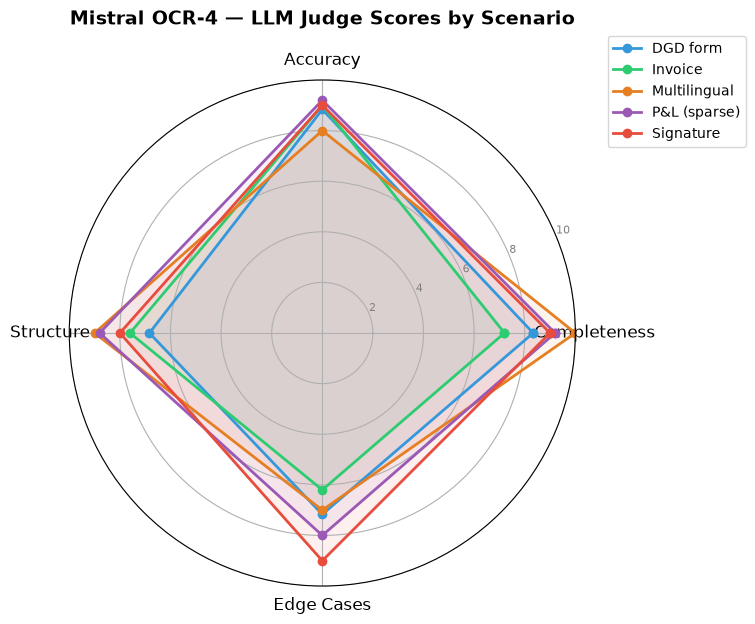

In [15]:
# Radar chart: per-scenario average scores
dims  = ['Completeness','Accuracy','Structure','Edge Cases']
scenario_groups = df_all.groupby('Scenario')[dims].mean()
N     = len(dims)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

palette = ['#3498DB','#2ECC71','#E67E22','#9B59B6','#E74C3C']
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, (scenario, row) in enumerate(scenario_groups.iterrows()):
    values = list(row.values) + [row.values[0]]
    ax.plot(angles, values, 'o-', linewidth=2, color=palette[i % len(palette)], label=scenario)
    ax.fill(angles, values, alpha=0.08, color=palette[i % len(palette)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(dims, fontsize=12)
ax.set_ylim(0, 10)
ax.set_yticks([2,4,6,8,10])
ax.set_yticklabels(['2','4','6','8','10'], fontsize=8, color='grey')
ax.set_title('Mistral OCR-4 — LLM Judge Scores by Scenario', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout()
plt.show()


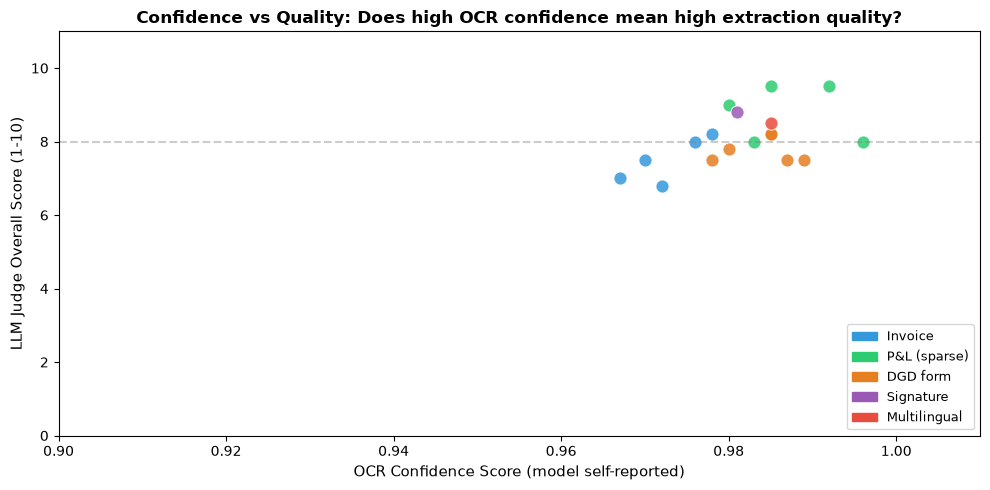


If all points cluster at high confidence but vary widely in judge score,
the confidence score is overconfident and should not be used as a quality gate.


In [16]:
# Confidence vs Judge score: does a high confidence score predict quality?
scenario_colors = {
    'Invoice':      '#3498DB',
    'P&L (sparse)': '#2ECC71',
    'DGD form':     '#E67E22',
    'Signature':    '#9B59B6',
    'Multilingual': '#E74C3C',
}
fig, ax = plt.subplots(figsize=(10, 5))
for _, row in df_all.iterrows():
    color = scenario_colors.get(row['Scenario'], '#888888')
    ax.scatter(row['OCR Conf'], row['Overall'], color=color, s=90,
               alpha=0.85, edgecolors='white', linewidths=0.8)

legend_handles = [mpatches.Patch(color=c, label=s) for s, c in scenario_colors.items()]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)
ax.set_xlabel('OCR Confidence Score (model self-reported)', fontsize=11)
ax.set_ylabel('LLM Judge Overall Score (1-10)', fontsize=11)
ax.set_title(
    'Confidence vs Quality: Does high OCR confidence mean high extraction quality?',
    fontsize=12, fontweight='bold'
)
ax.set_xlim(0.9, 1.01)
ax.set_ylim(0, 11)
ax.axhline(8, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
print()
print('If all points cluster at high confidence but vary widely in judge score,')
print('the confidence score is overconfident and should not be used as a quality gate.')


---
## Key Findings & Recommendations

### What the OCR confidence score tells you
- That characters were **legible** to the model at the pixel level
- Whether image **resolution** is sufficient for recognition

### What the confidence score does NOT tell you
- Whether **table structure** was preserved correctly
- Whether **blank cells** in sparse tables are genuinely blank vs. accidentally dropped
- Whether all **regulatory fields** in complex forms were captured
- Whether **signature blocks** contain meaningful content (they almost never do)
- Whether **number formats** across languages were normalized correctly

### Scenario takeaways

| Scenario | OCR-4 strength | Gap the judge found |
|----------|----------------|---------------------|
| Invoices | Field extraction, line items | Minor date/number formatting differences |
| P&L / sparse | Section separation, headers | Empty-cell vs. zero distinction needs downstream logic |
| DGD forms | Multi-table separation | Nested regulatory sub-fields occasionally merge |
| Signatures | Block-type detection works | Content is intentionally empty — use for *presence*, not *content* |
| Multilingual (synthetic) | Accented chars, number formats | Synthetic test is too easy; real scanned docs required |

### Production recommendations
1. **Use `confidence < 0.85` as a human-review trigger**, not a quality guarantee above it
2. **Pair sparse table OCR with a downstream parser** that distinguishes `None`, `''`, and `0`
3. **Signature blocks** → use for form validation (signature present? yes/no), not content extraction
4. **For multilingual**: validate on real scanned documents in target languages
5. **LLM-as-judge** adds value in production QA loops where labeled ground truth is unavailable
